In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
pink = "#FF6392"
yellow = "#FFE45E"
blue = '#6096BA'
purple = '#642CA9'

## Statistical Difference of the SVC Model

In [11]:
#import stats from ica model performance
matched = np.load('matched_data.npy')

In [12]:
#import stats from ca model performance
hem = np.load('hemisphere_data.npy')

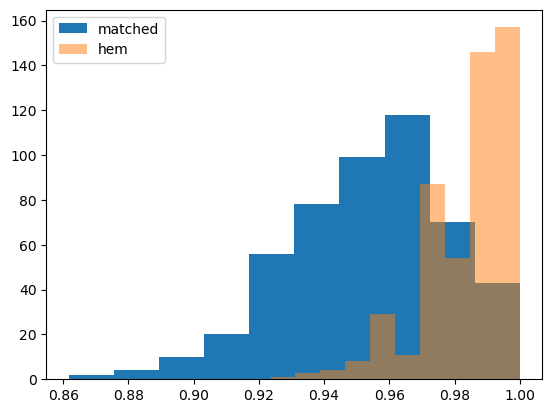

In [13]:
plt.hist(matched, label='matched', bins=10)
plt.hist(hem, label='hem', alpha=0.5,bins=10)
plt.legend()

In [14]:
stat, p_value = stats.wilcoxon(matched, hem)

alpha=0.05
if p_value < alpha:
    print("Significant difference between ICA and Hemisphere parcellation performance.")
else:
    print("No significant difference between ICA and Hemisphere parcellation performance.")


Significant difference between ICA and Hemisphere parcellation performance.


In [15]:
import numpy as np

def bootstrap_ci(data1, data2, n_bootstrap=10000, confidence=0.95):
    """Computes bootstrap confidence intervals for the difference in means"""
    boot_diffs = []
    np.random.seed(42)  # For reproducibility

    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=len(data1), replace=True)
        sample2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(sample2) - np.mean(sample1))  # Difference in means

    lower = np.percentile(boot_diffs, (1 - confidence) / 2 * 100)
    upper = np.percentile(boot_diffs, (1 + confidence) / 2 * 100)
    
    return lower, upper

# Compute 95% confidence interval for difference in performance
ci_lower, ci_upper = bootstrap_ci(matched, hem)

print(f"95% Bootstrapped Confidence Interval for the difference: ({ci_lower:.4f}, {ci_upper:.4f})")

if ci_lower < 0 and ci_upper > 0:
    print(f"0 is within our confidence interval and thus the difference between models is not significant")
else:
    print(f"0 is NOT within our confidence interval and thus the difference between models IS significant")

95% Bootstrapped Confidence Interval for the difference: (0.0295, 0.0344)
0 is NOT within our confidence interval and thus the difference between models IS significant


In [3]:
ba_m = np.load('balanced_acc_matched.npy')

In [4]:
ba_m

array([[  4.        ,   0.77967033],
       [  4.        ,   0.83124347],
       [  4.        ,   0.79638009],
       ...,
       [100.        ,   1.        ],
       [100.        ,   1.        ],
       [100.        ,   1.        ]], shape=(12500, 2))

In [7]:
np.unique(ba_h[:, 0])

array([  4.,   8.,  12.,  16.,  20.,  24.,  28.,  32.,  36.,  40.,  44.,
        48.,  52.,  56.,  60.,  64.,  68.,  72.,  76.,  80.,  84.,  88.,
        92.,  96., 100.])

In [6]:
ba_h = np.load('balanced_acc_hem.npy')

In [8]:
#matched ICA data
svc_m = np.load('SVC_acc_matched.npy')
knn_m = np.load('matched_data_knn.npy')
embed_reg_m = np.load('embed_reg_matched.npy')
knn_r_m = np.load('knn_reg_matched.npy')

##ca data
svc_ca = np.load('SVC_hem_data.npy')
knn_ca = np.load('ca_data_knn.npy')
embed_reg_ca = np.load('embed_reg_ca.npy')
knn_r_ca = np.load('knn_reg_ca.npy')

#ica all
svc_all = np.load('SVC_acc_icaall.npy')
knn_all = np.load('icaall_data_knn.npy')
embed_reg_all = np.load('embed_reg_icaall.npy')
knn_r_all = np.load('knn_reg_icaall.npy')

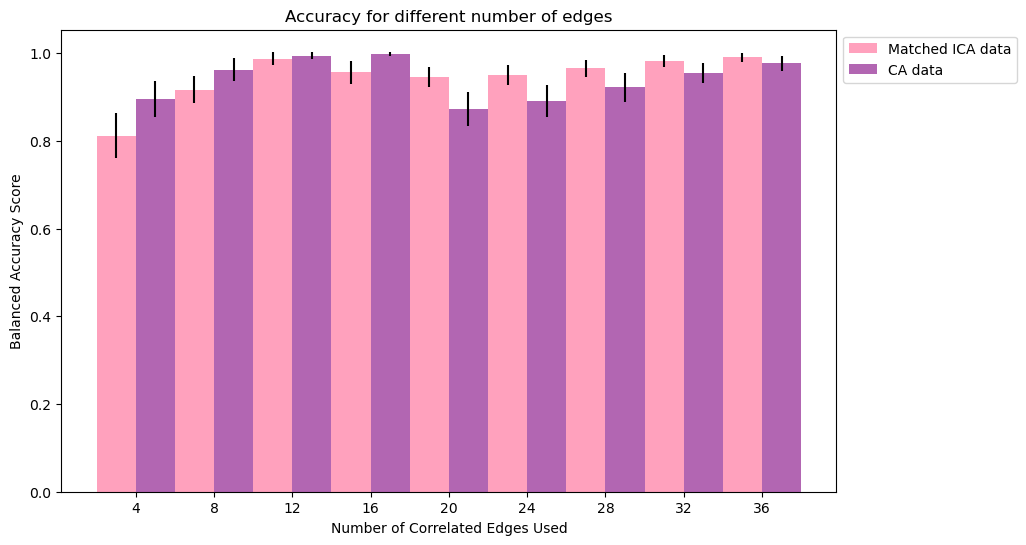

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Provided data
data1 = ba_m
data2 = ba_h

# Convert to DataFrame
df1 = pd.DataFrame(data1, columns=["Edges_Num", "Acc"])
df2 = pd.DataFrame(data2, columns=["Edges_Num", "Acc"])

# Filter specific values for Edges_Num
edges = [4, 8, 12, 16, 20, 24, 28, 32, 36]
df1_filtered = df1[df1["Edges_Num"].isin(edges)]
df2_filtered = df2[df2["Edges_Num"].isin(edges)]

# Compute mean & standard deviation
grouped1 = df1_filtered.groupby("Edges_Num")["Acc"]
mean1 = grouped1.mean()
std1 = grouped1.std()

grouped2 = df2_filtered.groupby("Edges_Num")["Acc"]
mean2 = grouped2.mean()
std2 = grouped2.std()

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 2  # Width of each bar
x = np.array(edges)  # Convert edges list to array for positioning

# Plot bars side by side
ax.bar(x - bar_width / 2, mean1, yerr=std1, width=bar_width, alpha=0.6, color=pink, label="Matched ICA data")
ax.bar(x + bar_width / 2, mean2, yerr=std2, width=bar_width, alpha=0.6, color="purple", label="CA data")

# Labels and title
ax.set_xticks(edges)
ax.set_xlabel("Number of Correlated Edges Used")
ax.set_ylabel("Balanced Accuracy Score")
ax.set_title("Accuracy for different number of edges")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))   # Add legend

plt.show()

fig.savefig('img/acc_diff_thresh.png', dpi=300, bbox_inches="tight")

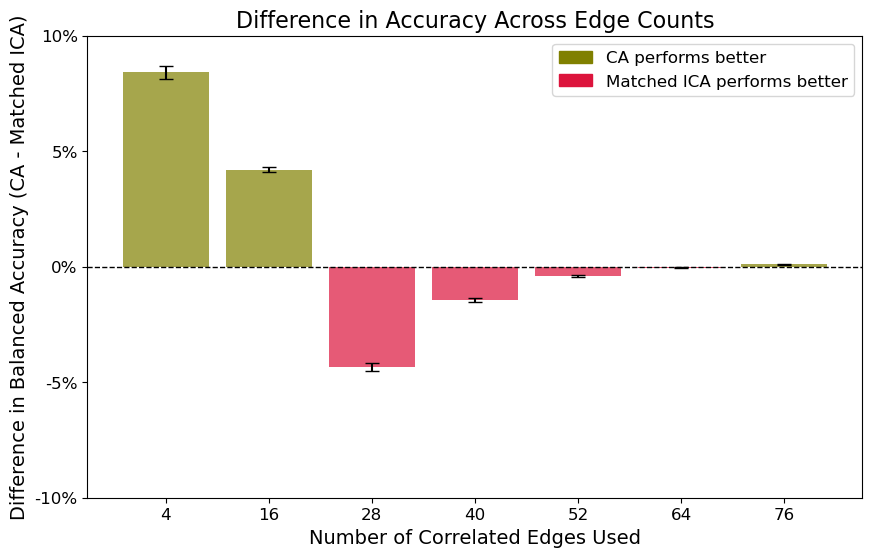

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Provided data
data1 = ba_m  # Matched ICA data
data2 = ba_h  # CA data

# Convert to DataFrame
df1 = pd.DataFrame(data1, columns=["Edges_Num", "Acc"])
df2 = pd.DataFrame(data2, columns=["Edges_Num", "Acc"])

# Filter specific values for Edges_Num
# edges = [4, 8, 12, 16, 20, 24, 28, 32, 36]
edges = np.unique(ba_h[:, 0])[:20:3]
df1_filtered = df1[df1["Edges_Num"].isin(edges)]
df2_filtered = df2[df2["Edges_Num"].isin(edges)]

# Compute mean & standard deviation
mean1 = df1_filtered.groupby("Edges_Num")["Acc"].mean()
std1 = df1_filtered.groupby("Edges_Num")["Acc"].std()
n1 = df1_filtered.groupby("Edges_Num")["Acc"].count()  # Sample count

mean2 = df2_filtered.groupby("Edges_Num")["Acc"].mean()
std2 = df2_filtered.groupby("Edges_Num")["Acc"].std()
n2 = df2_filtered.groupby("Edges_Num")["Acc"].count()  # Sample count

# Compute difference in means (CA - Matched ICA)
diff_means = mean2 - mean1

# Compute standard error of the mean (SEM) for difference
std_diff = np.sqrt((std1**2 / n1) + (std2**2 / n2))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 10  # Width of each bar

# Conditional coloring based on whether CA or Matched ICA is better
colors = np.where(diff_means > 0, 'olive', 'crimson')  # Green for CA better, Red for ICA better

# Plot bars with conditional colors
bars = ax.bar(edges, diff_means, yerr=std_diff, width=bar_width, 
              alpha=0.7, color=colors, capsize=5)

# Add a horizontal line at 0 for reference
ax.axhline(0, color="black", linestyle="--", linewidth=1)

# Labels and title
ax.set_xticks(edges)
ax.set_yticks([-0.1, -0.05, 0, 0.05, 0.1])
ax.set_xlabel("Number of Correlated Edges Used", fontsize=14)
ax.set_ylabel("Difference in Balanced Accuracy (CA - Matched ICA)", fontsize=14)
ax.set_title("Difference in Accuracy Across Edge Counts", fontsize=16)

# Convert y-ticks to percentages
def percent(x, pos):
    return f'{x * 100:.0f}%'  # Convert to percentage and format

ax.yaxis.set_major_formatter(FuncFormatter(percent))


# Improve tick size
ax.tick_params(axis="both", labelsize=12)

# Add a legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(color='olive', label='CA performs better'),
                   Patch(color='crimson', label='Matched ICA performs better')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Show and save plot
plt.show()
fig.savefig('report/acc_diff_thresh.png', dpi=300, bbox_inches="tight")


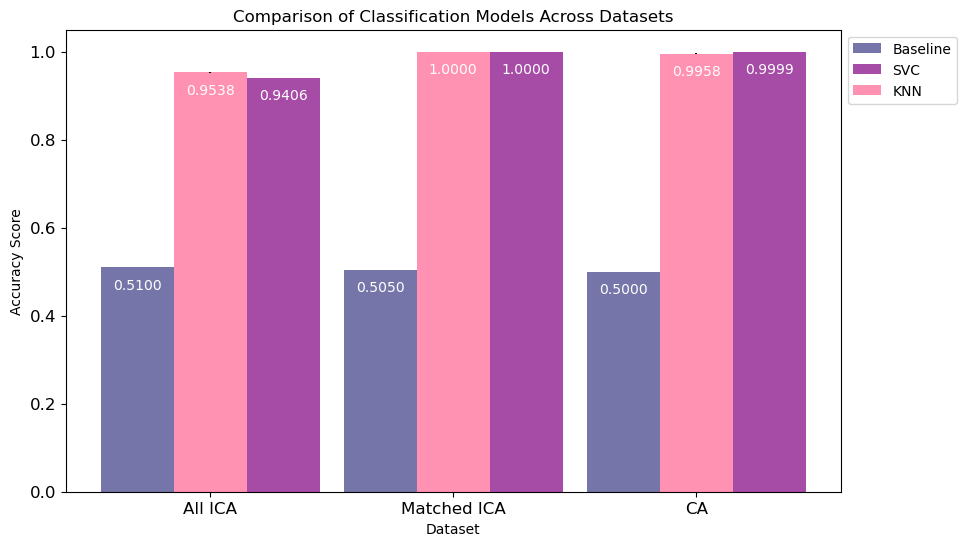

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem

# Example data: Each row is a dataset, and values are results for that dataset
np.random.seed(42)
data1 =   np.vstack((svc_all, svc_m, svc_ca))# Simulated dataset results for Model 1
data2 = np.vstack((knn_all[:, 2], knn_m[:, 2], knn_ca[:, 2]))  # Simulated dataset results for Model 2

# Compute mean and standard error of the mean (SEM)
mean1 = np.mean(data1, axis=1)
std1 = sem(data1, axis=1)

mean2 = np.mean(data2, axis=1)
std2 = sem(data2, axis=1)

# Fixed reference values at 0.5
fixed_values = [0.51, 0.505, 0.5]#np.full(len(mean1), 0.5)

# Plot settings
n_datasets = len(mean1)
bar_width = 0.3  # Adjust width to fit all bars
x = np.arange(n_datasets)  # X positions for datasets

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars with error bars
bars1 = ax.bar(x - bar_width, fixed_values, width=bar_width, alpha=0.6, color="midnightblue", label="Baseline")
bars2 = ax.bar(x + bar_width, mean1, yerr=std1, width=bar_width, alpha=0.7, color="purple", label="SVC")
bars3 = ax.bar(x, mean2, yerr=std2, width=bar_width, alpha=0.7, color=pink, label="KNN")
# bars3 = ax.bar(x + bar_width, fixed_values, width=bar_width, alpha=0.6, color="blue", label="Fixed 0.5")

# Add mean value annotations
for bars in [bars1, bars2, bars3]:  
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height - 0.05, f"{height:.4f}", ha='center', fontsize=10, fontweight="normal", color="white")

# Formatting
ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in ['All ICA', 'Matched ICA', 'CA']])
ax.set_xlabel("Dataset")
ax.set_ylabel("Accuracy Score")
ax.set_title("Comparison of Classification Models Across Datasets")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))  # Add legend outside
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))  # Add legend outside
ax.tick_params(axis='both', labelsize=12)

plt.show()

fig.savefig('report/class_analysis.png', dpi=300, bbox_inches="tight")

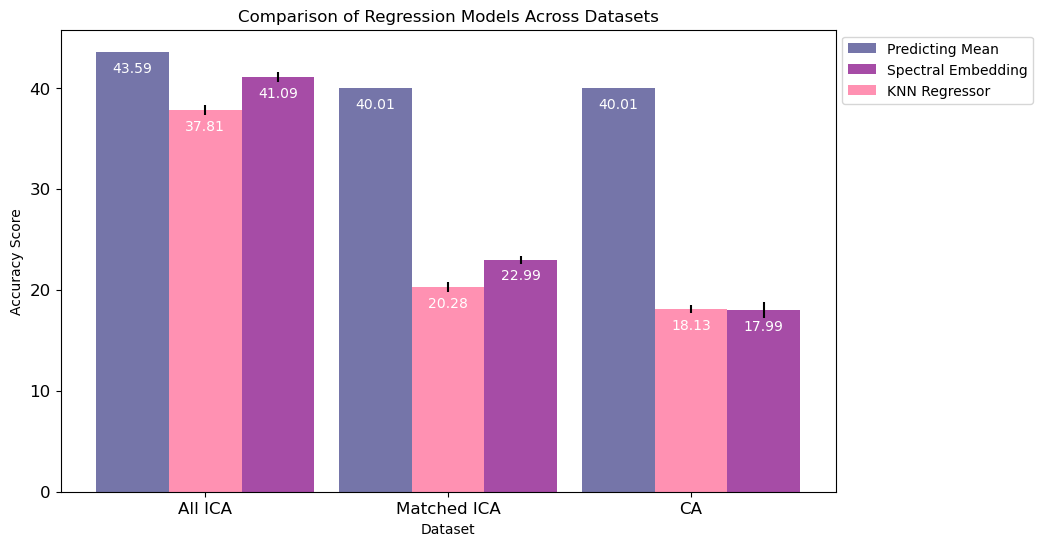

In [26]:
# Example data: Each row is a dataset, and values are results for that dataset
np.random.seed(42)
data1 =  np.vstack((embed_reg_all[:,1], embed_reg_m[:,1], embed_reg_ca[:,1]))# Simulated dataset results for Model 1
data2 = np.vstack((knn_r_all, knn_r_m, knn_r_ca))  # Simulated dataset results for Model 2

data1 = data1**0.5
data2 = data2**0.5

# Compute mean and standard error of the mean (SEM)
mean1 = np.mean(data1, axis=1)
std1 = sem(data1, axis=1)

mean2 = np.mean(data2, axis=1)
std2 = sem(data2, axis=1)

# Fixed reference values at 0.5
fixed_values = [1899.7987095542885**0.5, 1600.6023875114786**0.5, 1600.60238**0.5]#np.full(len(mean1), 0.5)

# Plot settings
n_datasets = len(mean1)
bar_width = 0.3  # Adjust width to fit all bars
x = np.arange(n_datasets)  # X positions for datasets

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars with error bars
bars1 = ax.bar(x - bar_width, fixed_values, width=bar_width, alpha=0.6, color="midnightblue", label="Predicting Mean")
bars2 = ax.bar(x + bar_width, mean1, yerr=std1, width=bar_width, alpha=0.7, color="purple", label="Spectral Embedding")
bars3 = ax.bar(x, mean2, yerr=std2, width=bar_width, alpha=0.7, color=pink, label="KNN Regressor")
# bars3 = ax.bar(x + bar_width, fixed_values, width=bar_width, alpha=0.6, color="blue", label="Fixed 0.5")

# Add mean value annotations
for bars in [bars1, bars2, bars3]:  
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height - 2, f"{height:.2f}", ha='center', fontsize=10, fontweight="normal", color='white')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in ['All ICA', 'Matched ICA', 'CA']])
ax.set_xlabel("Dataset")
ax.set_ylabel("Accuracy Score")
ax.set_title("Comparison of Regression Models Across Datasets")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))  # Add legend outside
ax.tick_params(axis='both', labelsize=12)

plt.show()

fig.savefig('report/regression_analysis.png', dpi=300, bbox_inches="tight")